# Notebook 1: Espacio de probabilidad

## Diplomado - Módulo II: Técnicas Estadísticas

Este notebook desarrolla los fundamentos del espacio de probabilidad: su definición formal, los conceptos de espacio muestral y evento, los axiomas de Kolmogorov, la probabilidad condicional y la independencia. También se presentan los tres enfoques clásicos para asignar probabilidades (clásico, frecuentista y geométrico) junto con ejemplos clásicos (problema del encuentro, ejemplo del volado) y un ejemplo adicional propio (problema del cumpleaños).

En cada tema se incluye primero la explicación conceptual y después el código en Python. Los cálculos con `print` y las gráficas se colocan en celdas de código separadas.

In [3]:
# Bibliotecas utilizadas en todo el notebook
import numpy as np
import matplotlib.pyplot as plt
from math import comb

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)

---
## 1. Definición de espacio de probabilidad

Un **espacio de probabilidad** es una terna $(\Omega, \mathcal{F}, P)$ donde:

- $\Omega$ es el **espacio muestral**: el conjunto de todos los resultados posibles de un experimento aleatorio.
- $\mathcal{F}$ es una **sigma-álgebra** de subconjuntos de $\Omega$: la colección de eventos a los que se les puede asignar una probabilidad.
- $P$ es una **medida de probabilidad**, es decir, una función $P: \mathcal{F} \to [0, 1]$ que satisface los axiomas de Kolmogorov (sección 3).

Esta estructura formaliza la idea intuitiva de "experimento aleatorio": $\Omega$ describe qué puede pasar, $\mathcal{F}$ describe qué preguntas (eventos) se pueden hacer, y $P$ asigna un número entre 0 y 1 a cada pregunta que representa qué tan probable es.

---
## 2. Espacio muestral $\Omega$ y eventos

El **espacio muestral** $\Omega$ es el conjunto de todos los resultados posibles. Un **evento** es cualquier subconjunto de $\Omega$ (elemento de $\mathcal{F}$). Un evento puede ser:

- **Simple**: contiene un solo resultado.
- **Compuesto**: contiene más de un resultado.
- El **complemento** $A^c$ de un evento $A$ ocurre cuando $A$ no ocurre.
- La **unión** $A \cup B$ ocurre cuando ocurre $A$, $B$ o ambos.
- La **intersección** $A \cap B$ ocurre cuando ocurren $A$ y $B$ simultáneamente.

Ejemplo: se lanza un dado justo de 6 caras. El espacio muestral es $\Omega = \{1, 2, 3, 4, 5, 6\}$. Definimos el evento $A$ = "sale un número par" y $B$ = "sale un número menor o igual a 3".

In [4]:
# Espacio muestral del dado de 6 caras, representado como un conjunto de Python
omega = set(range(1, 7))

# Eventos como subconjuntos de omega
A = {2, 4, 6}   # A: "sale un numero par"
B = {1, 2, 3}   # B: "sale un numero menor o igual a 3"

complemento_A = omega - A
union_AB = A | B
interseccion_AB = A & B

print("Espacio muestral (Omega):", omega)
print("Evento A (numero par):", A)
print("Evento B (menor o igual a 3):", B)
print("Complemento de A:", complemento_A)
print("Union A U B:", union_AB)
print("Interseccion A n B:", interseccion_AB)

Espacio muestral (Omega): {1, 2, 3, 4, 5, 6}
Evento A (numero par): {2, 4, 6}
Evento B (menor o igual a 3): {1, 2, 3}
Complemento de A: {1, 3, 5}
Union A U B: {1, 2, 3, 4, 6}
Interseccion A n B: {2}


---
## 3. Axiomas de Kolmogorov

Una función $P$ es una medida de probabilidad sobre $(\Omega, \mathcal{F})$ si cumple:

1. **No negatividad**: $P(A) \ge 0$ para todo evento $A$.
2. **Normalización**: $P(\Omega) = 1$.
3. **Aditividad numerable**: si $A_1, A_2, \dots$ son eventos disjuntos entre sí, entonces $P\left(\bigcup_{i} A_i\right) = \sum_i P(A_i)$.

De estos axiomas se derivan propiedades útiles, entre ellas:

$$P(\emptyset) = 0, \qquad P(A^c) = 1 - P(A).$$

Se verifican numéricamente estas propiedades usando el dado de la sección anterior, asignando probabilidad uniforme $P(\{i\}) = 1/6$ a cada cara.

In [ ]:
# Probabilidad uniforme sobre el dado: cada cara tiene probabilidad 1/6
p = {cara: 1 / 6 for cara in omega}

p_omega = sum(p.values()) # Suma de todos sus valores de probabilidad, que debe ser 1
p_vacio = 0.0 # La probabilidad del conjunto vacío es 0
p_A = sum(p[c] for c in A) # La probabilidad del evento A
p_complemento_A = sum(p[c] for c in complemento_A) # La probabilidad del complemento de A

print("Axioma 1 (no negatividad): todas las P(i) son >= 0 ->", all(v >= 0 for v in p.values()))
print("Axioma 2 (normalizacion): P(Omega) =", p_omega)
print("Consecuencia: P(conjunto vacio) =", p_vacio)
print("Consecuencia: P(A) + P(A^c) =", round(p_A + p_complemento_A, 6), "(debe ser 1)")

Axioma 1 (no negatividad): todas las P(i) son >= 0 -> True
Axioma 2 (normalizacion): P(Omega) = 1.0
Consecuencia: P(conjunto vacio) = 0.0
Consecuencia: P(A) + P(A^c) = 1.0 (debe ser 1)


---
## 4. Probabilidad condicional

La **probabilidad condicional** de $A$ dado $B$ (con $P(B) > 0$) se define como

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}.$$

Representa la probabilidad de que ocurra $A$ una vez que se sabe que $B$ ya ocurrió. Ejemplo: en el dado, sea $A$ = "sale un número par" y $C$ = "sale un número mayor a 3". Se calcula $P(A \mid C)$.

In [6]:
# C: "sale un numero mayor a 3"
C = {4, 5, 6}
interseccion_A_C = A & C

p_C = sum(p[c] for c in C)
p_A_interseccion_C = sum(p[c] for c in interseccion_A_C)
p_A_dado_C = p_A_interseccion_C / p_C

print("Evento C (mayor a 3):", C)
print("A n C:", interseccion_A_C)
print("P(C) =", p_C)
print("P(A n C) =", p_A_interseccion_C)
print("P(A | C) = P(A n C) / P(C) =", round(p_A_dado_C, 4))

Evento C (mayor a 3): {4, 5, 6}
A n C: {4, 6}
P(C) = 0.5
P(A n C) = 0.3333333333333333
P(A | C) = P(A n C) / P(C) = 0.6667


---
## 5. Independencia

Dos eventos $A$ y $B$ son **independientes** si

$$P(A \cap B) = P(A) \cdot P(B).$$

Intuitivamente, saber que ocurrió $B$ no cambia la probabilidad de $A$. Se ilustra la diferencia entre un par de eventos independientes y uno dependiente lanzando dos dados simultáneamente:

- Par **independiente**: $A$ = "el primer dado es par", $B$ = "el segundo dado es impar" (dados distintos, sin relación).
- Par **dependiente**: $C$ = "el primer dado es par", $D$ = "la suma de ambos dados es mayor a 8" (D depende del resultado del primer dado).

In [7]:
rng = np.random.default_rng(42)
n_simulaciones = 200_000

dado1 = rng.integers(1, 7, size=n_simulaciones)
dado2 = rng.integers(1, 7, size=n_simulaciones)

# Par independiente
A_ind = dado1 % 2 == 0
B_ind = dado2 % 2 == 1
p_A_ind = A_ind.mean()
p_B_ind = B_ind.mean()
p_AB_ind = (A_ind & B_ind).mean()

print("Par independiente (A, B)")
print("P(A) =", round(p_A_ind, 4))
print("P(B) =", round(p_B_ind, 4))
print("P(A) * P(B) =", round(p_A_ind * p_B_ind, 4))
print("P(A n B) simulada =", round(p_AB_ind, 4))

# Par dependiente
suma = dado1 + dado2
C_dep = dado1 % 2 == 0
D_dep = suma > 8
p_C_dep = C_dep.mean()
p_D_dep = D_dep.mean()
p_CD_dep = (C_dep & D_dep).mean()

print("\nPar dependiente (C, D)")
print("P(C) =", round(p_C_dep, 4))
print("P(D) =", round(p_D_dep, 4))
print("P(C) * P(D) =", round(p_C_dep * p_D_dep, 4))
print("P(C n D) simulada =", round(p_CD_dep, 4))

Par independiente (A, B)
P(A) = 0.5013
P(B) = 0.5019
P(A) * P(B) = 0.2516
P(A n B) simulada = 0.2521

Par dependiente (C, D)
P(C) = 0.5013
P(D) = 0.279
P(C) * P(D) = 0.1398
P(C n D) simulada = 0.1675


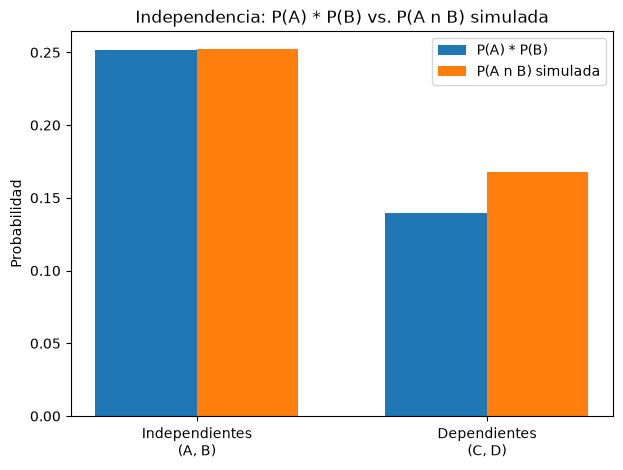

In [8]:
etiquetas = ["Independientes\n(A, B)", "Dependientes\n(C, D)"]
productos = [p_A_ind * p_B_ind, p_C_dep * p_D_dep]
conjuntas = [p_AB_ind, p_CD_dep]

x = np.arange(len(etiquetas))
ancho = 0.35

fig, ax = plt.subplots()
ax.bar(x - ancho / 2, productos, ancho, label="P(A) * P(B)")
ax.bar(x + ancho / 2, conjuntas, ancho, label="P(A n B) simulada")
ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.set_ylabel("Probabilidad")
ax.set_title("Independencia: P(A) * P(B) vs. P(A n B) simulada")
ax.legend()
plt.show()

**Interpretación:** en el par independiente, las barras de $P(A)\cdot P(B)$ y $P(A \cap B)$ prácticamente coinciden, confirmando la independencia. En el par dependiente, ambas barras difieren claramente: conocer que el primer dado es par sí cambia la probabilidad de que la suma sea mayor a 8.

---
## 6. Enfoque clásico (regla de Laplace)

Cuando todos los resultados de $\Omega$ son igualmente probables (finito y equiprobable), la probabilidad de un evento $A$ se calcula como

$$P(A) = \frac{\text{número de casos favorables}}{\text{número de casos totales}} = \frac{|A|}{|\Omega|}.$$

Ejemplo: probabilidad de obtener un número primo al lanzar un dado.

In [9]:
primos = {2, 3, 5}

p_clasica = len(primos) / len(omega)

print("Casos favorables (numeros primos en el dado):", primos)
print("Numero de casos favorables:", len(primos))
print("Numero de casos totales:", len(omega))
print("P(numero primo) =", round(p_clasica, 4))

Casos favorables (numeros primos en el dado): {2, 3, 5}
Numero de casos favorables: 3
Numero de casos totales: 6
P(numero primo) = 0.5


---
## 7. Enfoque frecuentista

El enfoque frecuentista define la probabilidad de un evento como el límite de su **frecuencia relativa** al repetir el experimento un número muy grande de veces:

$$P(A) = \lim_{n \to \infty} \frac{\text{número de veces que ocurre } A}{n}.$$

Se simulan volados de una moneda justa y se observa cómo la frecuencia relativa de "cara" se estabiliza alrededor de 0.5 conforme aumenta el número de lanzamientos.

In [32]:
rng = np.random.default_rng(677)
n_max = 20_000
volados = rng.integers(0, 2, size=n_max)  # 1 = cara, 0 = cruz

tamanos = np.arange(1, n_max + 1)
frecuencia_relativa = np.cumsum(volados) / tamanos

print("Frecuencia relativa de caras tras 10 volados:", round(frecuencia_relativa[9], 4))
print("Frecuencia relativa de caras tras 1000 volados:", round(frecuencia_relativa[999], 4))
print(f"Frecuencia relativa de caras tras {n_max} volados:", round(frecuencia_relativa[-1], 4))

Frecuencia relativa de caras tras 10 volados: 0.6
Frecuencia relativa de caras tras 1000 volados: 0.504
Frecuencia relativa de caras tras 20000 volados: 0.5024


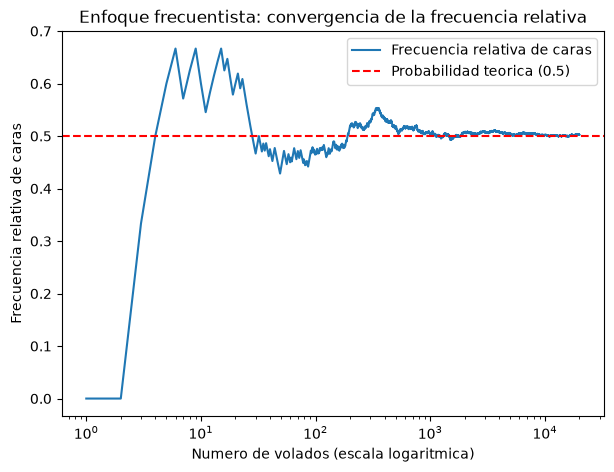

In [33]:
plt.figure()
plt.plot(tamanos, frecuencia_relativa, label="Frecuencia relativa de caras")
plt.axhline(0.5, color="red", linestyle="--", label="Probabilidad teorica (0.5)")
plt.xscale("log")
plt.xlabel("Numero de volados (escala logaritmica)")
plt.ylabel("Frecuencia relativa de caras")
plt.title("Enfoque frecuentista: convergencia de la frecuencia relativa")
plt.legend()
plt.show()

**Interpretación:** al principio la frecuencia relativa oscila bastante (con pocos volados el azar domina), pero conforme el número de lanzamientos crece, la curva se estabiliza y se aproxima a la probabilidad teórica de 0.5, ilustrando la idea frecuentista de probabilidad.

---
## 8. Enfoque geométrico

En el enfoque geométrico, el espacio muestral es una región continua (longitud, área o volumen) y la probabilidad de un evento es la razón entre la medida del evento y la medida total del espacio:

$$P(A) = \frac{\text{área}(A)}{\text{área}(\Omega)}.$$

Ejemplo clásico: estimar $\pi$ generando puntos aleatorios uniformes en el cuadrado $[-1, 1] \times [-1, 1]$ y calculando la proporción que cae dentro del círculo unitario inscrito. Como el área del círculo es $\pi r^2 = \pi$ y la del cuadrado es 4, la proporción esperada de puntos dentro del círculo es $\pi / 4$.

In [34]:
rng = np.random.default_rng(777)
n_puntos = 20_000
x = rng.uniform(-1, 1, n_puntos)
y = rng.uniform(-1, 1, n_puntos)
dentro_circulo = x**2 + y**2 <= 1

p_dentro = dentro_circulo.mean()
pi_estimado = p_dentro * 4

print("Proporcion de puntos dentro del circulo:", round(p_dentro, 4))
print("Estimacion de pi (4 * proporcion):", round(pi_estimado, 4))
print("Valor real de pi:", round(np.pi, 4))

Proporcion de puntos dentro del circulo: 0.7905
Estimacion de pi (4 * proporcion): 3.162
Valor real de pi: 3.1416


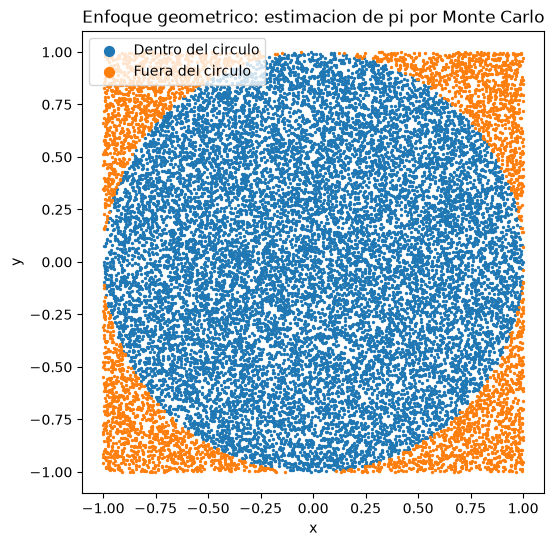

In [35]:
plt.figure(figsize=(6, 6))
plt.scatter(x[dentro_circulo], y[dentro_circulo], s=2, color="tab:blue", label="Dentro del circulo")
plt.scatter(x[~dentro_circulo], y[~dentro_circulo], s=2, color="tab:orange", label="Fuera del circulo")
plt.gca().set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Enfoque geometrico: estimacion de pi por Monte Carlo")
plt.legend(markerscale=5)
plt.show()

---
## 9. Problema del encuentro

Dos personas acuerdan verse en un lugar durante la hora entre las 12:00 y la 13:00. Cada una llega en un instante aleatorio uniforme dentro de esa hora, y se encuentran solo si ninguna espera más de $\Delta$ (una fracción de hora) a la otra. Sean $X, Y \sim \text{Uniforme}(0, 1)$ los tiempos de llegada (en fracción de hora) de cada persona, independientes entre sí. Se encuentran si

$$|X - Y| < \Delta.$$

Este evento corresponde a una banda diagonal dentro del cuadrado unitario $[0,1]\times[0,1]$. Calculando el área de esa banda se obtiene la probabilidad teórica

$$P(|X-Y| < \Delta) = 1 - (1 - \Delta)^2.$$

Se compara este resultado con una simulación Monte Carlo.

In [36]:
delta = 0.25  # ventana de encuentro: 15 minutos de una hora

p_teorica = 1 - (1 - delta) ** 2

rng = np.random.default_rng(3)
n_sim = 100_000
X = rng.uniform(0, 1, n_sim)
Y = rng.uniform(0, 1, n_sim)
se_encuentran = np.abs(X - Y) < delta
p_simulada = se_encuentran.mean()

print("Delta (ventana de encuentro):", delta)
print("Probabilidad teorica (area de la banda):", round(p_teorica, 4))
print("Probabilidad simulada:", round(p_simulada, 4))

Delta (ventana de encuentro): 0.25
Probabilidad teorica (area de la banda): 0.4375
Probabilidad simulada: 0.4371


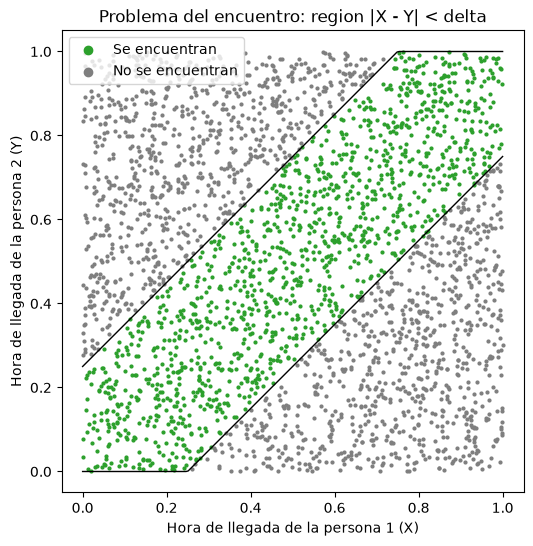

In [15]:
n_muestra_grafica = 3000
idx = rng.choice(n_sim, n_muestra_grafica, replace=False)

plt.figure(figsize=(6, 6))
plt.scatter(X[idx][se_encuentran[idx]], Y[idx][se_encuentran[idx]], s=4, color="tab:green", label="Se encuentran")
plt.scatter(X[idx][~se_encuentran[idx]], Y[idx][~se_encuentran[idx]], s=4, color="tab:gray", label="No se encuentran")
t = np.linspace(0, 1, 200)
plt.plot(t, np.clip(t + delta, 0, 1), color="black", linewidth=1)
plt.plot(t, np.clip(t - delta, 0, 1), color="black", linewidth=1)
plt.gca().set_aspect("equal")
plt.xlabel("Hora de llegada de la persona 1 (X)")
plt.ylabel("Hora de llegada de la persona 2 (Y)")
plt.title("Problema del encuentro: region |X - Y| < delta")
plt.legend(markerscale=3)
plt.show()

**Interpretación:** la región entre las dos rectas negras es la banda $|X-Y|<\Delta$. La proporción simulada de puntos verdes (que caen dentro de la banda) coincide, salvo el error propio de la simulación, con la probabilidad teórica calculada por área, confirmando la validez del enfoque geométrico.

---
## 10. Ejemplo del volado

Se lanza una moneda justa 5 veces. Bajo el enfoque clásico, el número de caras $k$ obtenido sigue la fórmula combinatoria

$$P(k \text{ caras}) = \binom{5}{k} (0.5)^k (0.5)^{5-k}, \qquad k = 0, 1, \dots, 5,$$

que es un caso particular de la distribución binomial (se retoma formalmente en el Notebook 2). Se compara esta probabilidad teórica contra la frecuencia obtenida al simular muchas repeticiones de 5 volados.

In [16]:
n_volados = 5
p_moneda = 0.5
k_valores = np.arange(0, n_volados + 1)
p_teorica_k = np.array([comb(n_volados, k) * p_moneda**k * (1 - p_moneda) ** (n_volados - k) for k in k_valores])

rng = np.random.default_rng(11)
n_repeticiones = 50_000
muestras = rng.integers(0, 2, size=(n_repeticiones, n_volados)).sum(axis=1)
frecuencia_simulada = np.array([(muestras == k).mean() for k in k_valores])

print("Numero de caras k:        ", k_valores)
print("Probabilidad teorica:     ", np.round(p_teorica_k, 4))
print("Frecuencia simulada:      ", np.round(frecuencia_simulada, 4))

Numero de caras k:         [0 1 2 3 4 5]
Probabilidad teorica:      [0.0312 0.1562 0.3125 0.3125 0.1562 0.0312]
Frecuencia simulada:       [0.031  0.1551 0.3149 0.3094 0.1572 0.0324]


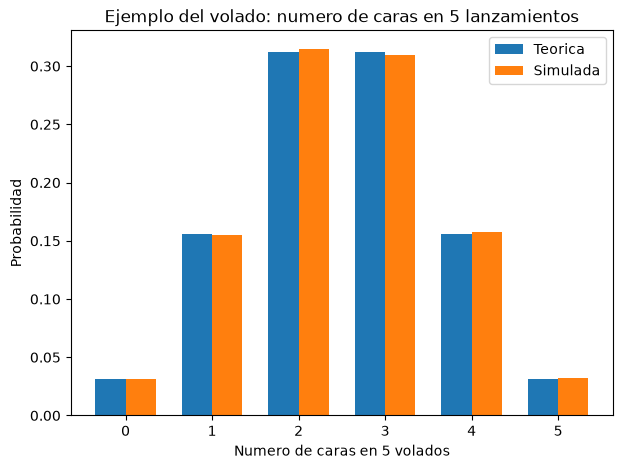

In [17]:
ancho = 0.35
fig, ax = plt.subplots()
ax.bar(k_valores - ancho / 2, p_teorica_k, ancho, label="Teorica")
ax.bar(k_valores + ancho / 2, frecuencia_simulada, ancho, label="Simulada")
ax.set_xticks(k_valores)
ax.set_xlabel("Numero de caras en 5 volados")
ax.set_ylabel("Probabilidad")
ax.set_title("Ejemplo del volado: numero de caras en 5 lanzamientos")
ax.legend()
plt.show()

---
## 11. Ejemplo adicional propio: el problema del cumpleaños

En un grupo de $n$ personas (con $n \le 365$), suponiendo cumpleaños independientes y uniformemente distribuidos entre los 365 días del año, se busca la probabilidad de que **al menos dos personas** compartan cumpleaños.

Es más fácil calcular primero la probabilidad del complemento (que **nadie** comparta cumpleaños):

$$P(\text{sin coincidencias}) = \prod_{i=0}^{n-1} \frac{365 - i}{365},$$

de modo que

$$P(\text{al menos una coincidencia}) = 1 - \prod_{i=0}^{n-1} \frac{365 - i}{365}.$$

Este es un ejemplo clásico de probabilidad, se incluye aquí como ejemplo adicional. Se calcula la probabilidad teórica para distintos tamaños de grupo y se compara con una simulación Monte Carlo.

In [ ]:
def prob_coincidencia_teorica(n, dias=365):
    """Probabilidad de al menos una coincidencia de cumpleanos en un grupo de tamano n."""
    p_sin_coincidencia = 1.0
    for i in range(n):
        p_sin_coincidencia *= (dias - i) / dias
    return 1 - p_sin_coincidencia


tamanos_grupo = np.arange(2, 61)
p_teorica_cumple = np.array([prob_coincidencia_teorica(n) for n in tamanos_grupo])

n_ejemplo = 29 # numero de personas en el diplomado
print(f"Probabilidad teorica de coincidencia con {n_ejemplo} personas:",
      round(prob_coincidencia_teorica(n_ejemplo), 4))

Probabilidad teorica de coincidencia con 29 personas: 0.681


In [43]:
def prob_coincidencia_simulada(n, dias=365, n_sim=20_000, rng=None):
    """Estima por simulacion la probabilidad de al menos una coincidencia de cumpleanos."""
    if rng is None:
        rng = np.random.default_rng()
    grupos = rng.integers(0, dias, size=(n_sim, n))
    grupos_ordenados = np.sort(grupos, axis=1)
    hay_coincidencia = (np.diff(grupos_ordenados, axis=1) == 0).any(axis=1)
    return hay_coincidencia.mean()


rng = np.random.default_rng(5)
tamanos_grupo_sim = np.arange(2, 61, 4)
p_simulada_cumple = np.array([prob_coincidencia_simulada(n, rng=rng) for n in tamanos_grupo_sim])

print(f"Probabilidad simulada de coincidencia con {n_ejemplo} personas:",
      round(prob_coincidencia_simulada(n_ejemplo, n_sim=20_000, rng=rng), 4))

Probabilidad simulada de coincidencia con 29 personas: 0.6778


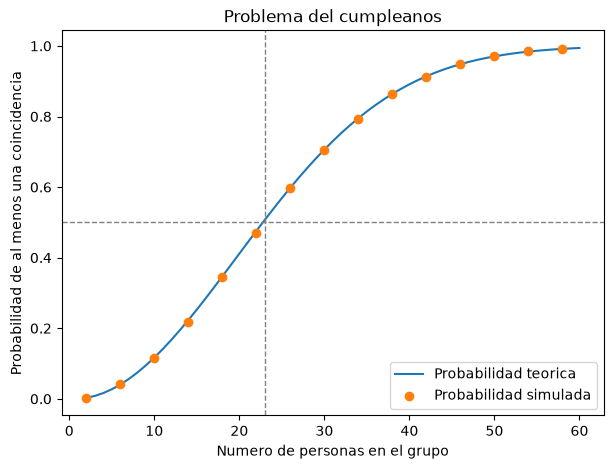

In [39]:
plt.figure()
plt.plot(tamanos_grupo, p_teorica_cumple, label="Probabilidad teorica")
plt.scatter(tamanos_grupo_sim, p_simulada_cumple, color="tab:orange", label="Probabilidad simulada", zorder=3)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.axvline(23, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Numero de personas en el grupo")
plt.ylabel("Probabilidad de al menos una coincidencia")
plt.title("Problema del cumpleanos")
plt.legend()
plt.show()

---
## 12. Conclusión del Notebook 1

El espacio de probabilidad $(\Omega, \mathcal{F}, P)$ da un marco formal para razonar sobre experimentos aleatorios: $\Omega$ enumera los resultados posibles, los eventos son subconjuntos de interés y $P$, sujeta a los axiomas de Kolmogorov, asigna una medida coherente de probabilidad. Sobre esta base se construyen la probabilidad condicional y la independencia, que permiten actualizar creencias y describir la relación (o falta de relación) entre eventos.

Los tres enfoques presentados (clásico, frecuentista y geométrico) son formas distintas de **calcular** probabilidades según el tipo de experimento: el clásico funciona con resultados equiprobables y finitos, el frecuentista aproxima la probabilidad mediante la repetición del experimento, y el geométrico extiende la idea a espacios continuos usando razones de longitudes o áreas. Los ejemplos trabajados (volados, problema del encuentro y problema del cumpleaños) muestran que, en todos los casos, la simulación en Python confirma los resultados obtenidos analíticamente, reforzando la conexión entre la teoría y la práctica computacional.

## Bibliografía

- [Rincón, L. (2014). *Curso elemental de probabilidad y estadística*. Facultad de Ciencias, UNAM.](https://www.cimat.mx/~pabreu/LuisRinconI.pdf)
- Ross, S. M. (2010). *A First Course in Probability* (8a ed.). Pearson.
- Mood, A. M., Graybill, F. A., & Boes, D. C. (1974). *Introduction to the Theory of Statistics* (3a ed.). McGraw-Hill.
- Mendenhall, W., Beaver, R. J., & Beaver, B. M. (2013). *Introduction to Probability and Statistics* (14a ed.). Cengage Learning.
- [Pishro-Nik, H. (2014). *Introduction to Probability, Statistics, and Random Processes*. ](https://www.probabilitycourse.com/preface.php?authuser=0) 